In [35]:
#Aufgabe 2_1
#Wir haben die Tabelle aus Aufgabe 1 übernommen.
#Zunächst wandeln wir zur Sicherheit alle 0 Werte in NA um, daraufhin droppen wir diese Zeilen.
import pandas as pd
import numpy as np
listings_2 = pd.read_csv("../Aufgabe 1/listings_1_13.csv", index_col="Unnamed: 0")
listings_2["price"] = listings_2["price"].replace(0, pd.NA)
listings_2.dropna(subset=["price"], inplace=True)

print(listings_2.columns)


listings_2_1 = listings_2[["price", "accommodates","latitude","longitude", "bedrooms", "host_is_superhost", "Shared_bath_status", "instant_bookable", "bathrooms_number"]]
#Drops NA
listings_2_1.dropna(inplace=True)
listings_2_1["price"] = listings_2_1["price"].apply(np.log)
listings_2_1.rename(columns={"price":"log_price"}, inplace=True)
#We have checked that there are no NA values.  No further cleaning is necessary.

#print(len(listings_2["price"]))
#Ziel: Price
#Chosen Predictors: "region_median_price","latitude","longitude", "accommodates", "bedrooms", "host_is_superhost", "Shared_bath_status", instant_bookable", "bathrooms_number"
#listings_2_1.head()
#print(listings_2_1.isna().sum())
#Here we calculated the samplesize.
print(len(listings_2_1))

Index(['price', 'neighbourhood_cleansed', 'latitude', 'longitude', 'room_type',
       'bedrooms', 'bathrooms_number', 'accommodates', 'amenities',
       'host_is_superhost', 'host_listings_count', 'host_response_rate',
       'review_scores_rating', 'review_scores_cleanliness',
       'number_of_reviews', 'reviews_per_month', 'minimum_nights',
       'availability_365', 'instant_bookable', 'Shared_bath_status',
       'host_tenure_years', 'amenities_length', 'region_geo',
       'region_median_price', 'above_local_median'],
      dtype='str')
9203


Based upon the results of the previous task, we were able to see some of the chosen correlating parameters. We further added some of the parameters that were not included in the previous task, such as the number of bedrooms and bathrooms, because we believe they have a significant impact on the price of the house.

In [36]:
#Wir haben die Variablen latitude und longitude in eine Distanzvariable zum Stadtzentrum transformiert. Der Grund dafür ist, dass der Einfluss der Lage auf den Preis plausibel nicht linear entlang einer einzelnen geografischen Achse verläuft. Stattdessen ist zu erwarten, dass sich der Preiseffekt radial vom Stadtzentrum aus verändert, sodass vor allem die Entfernung zum Zentrum – und nicht die absolute Position in Nord-Süd- oder Ost-West-Richtung – für die Preisbildung relevant ist.
#Add distance from dataset geographic center using Euclidean distance.
   
lon_center = listings_2_1["longitude"].mean()
lat_center = listings_2_1["latitude"].mean()

listings_2_1["distance_center"] = np.sqrt(
    (listings_2_1["latitude"] - lat_center) ** 2 +
    (listings_2_1["longitude"] - lon_center) ** 2
)
  
listings_2_1 = listings_2_1.drop(columns=["latitude", "longitude"])

In [37]:
#Aufgabe_2_2
import statsmodels.api as sm
outcome = listings_2_1["log_price"]
regressor = listings_2_1.drop(columns=["log_price"])
regressor = sm.add_constant(regressor)

bool_cols = regressor.select_dtypes("bool").columns
regressor[bool_cols] = regressor[bool_cols].astype(int)
#print(regressor.dtypes)
olssim = sm.OLS(outcome, regressor)
olssim = olssim.fit()
olssim.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_price   R-squared:                       0.401
Model:                            OLS   Adj. R-squared:                  0.401
Method:                 Least Squares   F-statistic:                     881.1
Date:                Sat, 14 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:05:23   Log-Likelihood:                -6795.0
No. Observations:                9203   AIC:                         1.361e+04
Df Residuals:                    9195   BIC:                         1.366e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  4.1509      0.017    238.667      0.000       4.117       4.185
accommodates           0.0925      0.004     25.376      0.000       0.085       0.100
bedrooms               0.1130      0.009     12.398      0.000       0.095       0.131
host_is_superhost      0.0874      0.011      7.776      0.000       0.065       0.109
Shared_bath_status    -0.4749      0.015    -31.409      0.000      -0.504      -0.445
instant_bookable       0.2245      0.011     19.936      0.000       0.202       0.247
bathrooms_number       0.1131      0.012      9.102      0.000       0.089       0.138
distance_center       -1.3826      0.108    -12.840      0.000      -1.594      -1.172
==============================================================================
Omnibus:                     4183.145   Durbin-Watson:                   1.616
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           103392.575
Skew:                           1.632   Prob(JB):                         0.00
Kurtosis:                      19.093   Cond. No.                         90.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

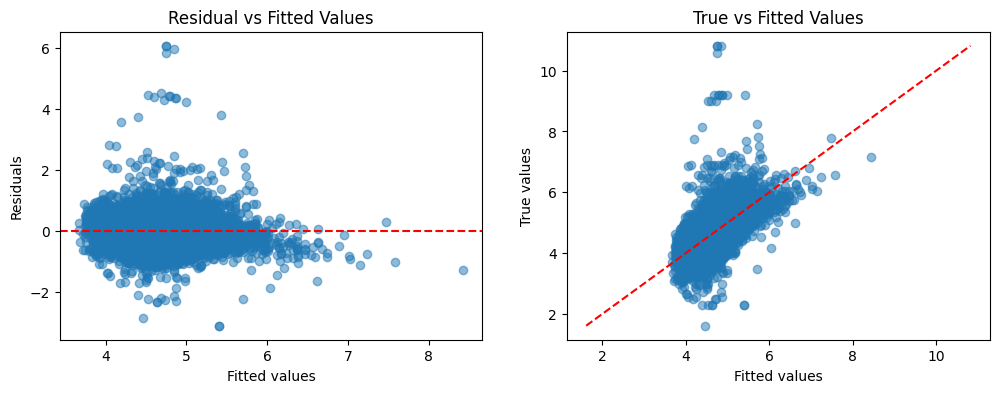

9203


In [38]:
#Aufgabe_2_3

import matplotlib.pyplot as plt

fitted = olssim.fittedvalues
residuals = olssim.resid

fig,ax = plt.subplots(1, 2,figsize=(12, 4))

ax[0].scatter(fitted, residuals, alpha=0.5)
ax[0].axhline(0, color='red', linestyle='--')
ax[0].set_xlabel("Fitted values")
ax[0].set_ylabel("Residuals")
ax[0].set_title("Residual vs Fitted Values")

ax[1].scatter(fitted, outcome, alpha=0.5)
ax[1].plot([outcome.min(), outcome.max()],[outcome.min(), outcome.max()], 'r--')
ax[1].set_xlabel("Fitted values")
ax[1].set_ylabel("True values")
ax[1].set_title("True vs Fitted Values")

plt.show()
print(len(outcome))

The residual-vs-fitted-values plot shows that the residuals are roughly centered around zero without a clear systematic pattern, suggesting that the linear specification of the model is reasonable. However, the spread of residuals appears to decrease slightly as the fitted values increase, which may indicate mild heteroskedasticity. A few outliers are also visible.
The residuals are centered around zero, indicating that the model does not systematically over- or underpredict the outcome.

In [39]:
#Aufgabe 2_4
from pyexpat import model

import sklearn.linear_model
# Initiate linear regression model
#from sklearn.linear_model import LinearRegression
#model = LinearRegression()


ridgecv_reg = sklearn.linear_model.RidgeCV(cv=10,fit_intercept = False)
model_ridge = ridgecv_reg.fit(regressor, outcome)

print(model_ridge.coef_)
Y2_est = model_ridge.predict(regressor) # Prediction for Y2
MSE = np.mean((outcome-Y2_est)**2)
print("Mean-Squared-Error:",MSE)
model_ridge.score(regressor, outcome)

[ 4.14999952  0.09249433  0.11295927  0.08751563 -0.47470451  0.22459553
  0.11333049 -1.37508499]
Mean-Squared-Error: 0.2563572620465808


0.40146342923061185

In [40]:
#AI generated code for ridge regression using numpy
# file: ridge_numpy.py
def ridge_estimate(X: np.ndarray, y: np.ndarray, lam: float) -> np.ndarray:

    X = np.asarray(X)
    y = np.asarray(y)
    p = X.shape[1]
    I = np.eye(p)
    beta_ridge = np.linalg.inv(X.T @ X + lam * I) @ (X.T @ y)

    return beta_ridge


def l2_norm(beta: np.ndarray) -> float:
    return np.sqrt(np.sum(beta ** 2))


def main():

    np.random.seed(0)

    n = 100
    p = 5

    X = np.random.randn(n, p)
    true_beta = np.array([2, -1, 0.5, 0, 1])
    y = X @ true_beta + np.random.randn(n)

    lambdas = [0.01, 1, 100]

    for lam in lambdas:
        beta_hat = ridge_estimate(X, y, lam)
        norm = l2_norm(beta_hat)

        print(f"lambda={lam}")
        print("beta_hat:", beta_hat)
        print("||beta||_2:", norm)
        print()
if __name__ == "__main__":
    main()

lambda=0.01
beta_hat: [ 2.04490578 -0.9212252   0.72683414 -0.00235475  0.91667279]
||beta||_2: 2.5296003495130224

lambda=1
beta_hat: [ 2.02360447e+00 -9.11666909e-01  7.19179575e-01  5.85448342e-06
  9.03651629e-01]
||beta||_2: 2.5019826417446165

lambda=100
beta_hat: [ 0.99827138 -0.45138015  0.34908802  0.05454171  0.36325514]
||beta||_2: 1.2070962369997345



The l_2-norm ||β||_2 is the smallest für the Ridge regression model, which suggests that it has the most regularization effect among the three models. This is expected, as Ridge regression adds a penalty term to the loss function that shrinks the coefficients towards zero, thus reducing their magnitude. The Lasso regression model has a larger l_2-norm than Ridge, but still smaller than the OLS model, indicating that it also applies some regularization but allows for some coefficients to be exactly zero. The OLS model has the largest l_2-norm, as it does not apply any regularization and allows all coefficients to take on their full values.


Lasso coefficients:
[ 0.          0.09255994  0.11280285  0.08732616 -0.47451323  0.22440385
  0.11295845 -1.36748772]
Eps: 1e-06
Alpha selected via cross-validation: 3.652383375544686e-05
L2 norm of coefficients: 1.4789252389961571


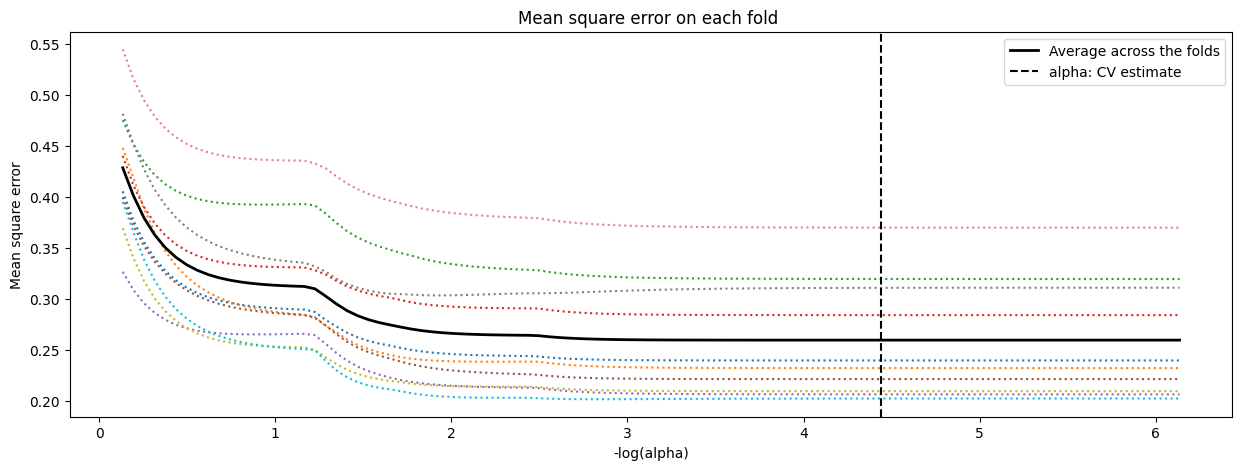

Zero-coefficient features:
['const']
Non-zero-coefficient features:
['accommodates', 'bedrooms', 'host_is_superhost', 'Shared_bath_status', 'instant_bookable', 'bathrooms_number', 'distance_center']


In [ ]:
#Aufgabe_2_5
lasso_reg = sklearn.linear_model.LassoCV(cv=10,fit_intercept = True, eps=1e-6)
model = lasso_reg.fit(regressor,outcome)
# Koeffizienten
print("Lasso coefficients:")
print(model.coef_)
print("Eps:", model.eps)

# Display results
# Alpha selected via cross-validation
print("Alpha selected via cross-validation:", model.alpha_)

# L2-Norm der Koeffizienten
print("L2 norm of coefficients:", np.linalg.norm(model.coef_, 2))

m_log_alphas = -np.log10(model.alphas_)
plt.figure(1,figsize=(15,5))
plt.plot(m_log_alphas, model.mse_path_, ':')
plt.plot(m_log_alphas, model.mse_path_.mean(axis=-1), 'k',
         label='Average across the folds', linewidth=2)
plt.axvline(-np.log10(model.alpha_), linestyle='--', color='k',
            label='alpha: CV estimate')
plt.legend()
plt.xlabel('-log(alpha)')
plt.ylabel('Mean square error')
plt.title('Mean square error on each fold ')
plt.axis('tight')
plt.show()
#List which features are zero and which are not
zero_mask = model.coef_ == 0
nonzero_mask = model.coef_ != 0
zero_features = regressor.columns[zero_mask]
nonzero_features = regressor.columns[nonzero_mask]

print("Zero-coefficient features:")
print(list(zero_features))
print("Non-zero-coefficient features:")
print(list(nonzero_features))

Lasso coefficients:
[ 4.1508587   0.09246958  0.11297681  0.08741038 -0.47483642  0.22447879
  0.11313824 -1.3818588 ]
Alpha selected via cross-validation: 1.6244355557491955e-06
L2 norm of coefficients: 4.410983710721852


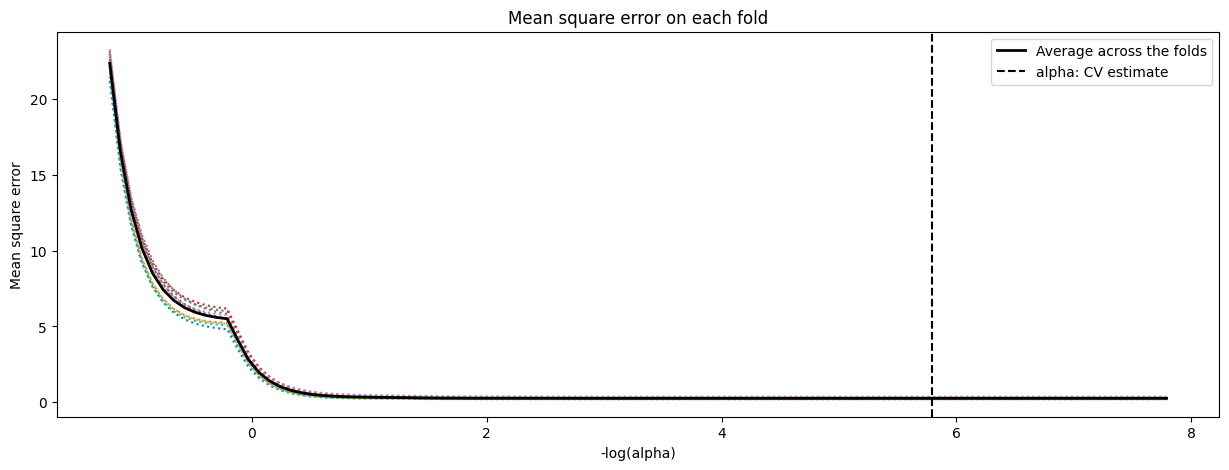

In [47]:
# Aufgabe_2_5

lasso_reg = sklearn.linear_model.LassoCV(cv=10, fit_intercept=False, eps=1e-9)
model = lasso_reg.fit(regressor, outcome)

# Koeffizienten
print("Lasso coefficients:")
print(model.coef_)

# Alpha selected via cross-validation
print("Alpha selected via cross-validation:", model.alpha_)

# L2-Norm der Koeffizienten
print("L2 norm of coefficients:", np.linalg.norm(model.coef_, 2))

# Display results
m_log_alphas = -np.log10(model.alphas_)

plt.figure(1, figsize=(15,5))

plt.plot(m_log_alphas, model.mse_path_, ':')
plt.plot(
    m_log_alphas,
    model.mse_path_.mean(axis=-1),
    'k',
    label='Average across the folds',
    linewidth=2
)

plt.axvline(
    -np.log10(model.alpha_),
    linestyle='--',
    color='k',
    label='alpha: CV estimate'
)

plt.legend()
plt.xlabel('-log(alpha)')
plt.ylabel('Mean square error')
plt.title('Mean square error on each fold')
plt.axis('tight')
plt.show()